# Tea-vs-Coffee-Lifestyle-Report

## Problems we are solving
### Global landscape — where tea and coffee dominate 
### Change over time — whether preferences are shifting 
### Who drinks what — age, gender, income and time of the day
### Why they drink it — motivation and daily rhythm 
### What it means — satisfaction, loyalty, wellness, business insight 

## Import necessary Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (12, 7)

shared_cmap = LinearSegmentedColormap.from_list(
    "custom_pink_red",
    ['#fbe6eb', '#f4a6b7', '#800000']
)

### Load Data

In [4]:
df = pd.read_excel("/Users/deepti/Documents/My projects/tea_vs_coffee_global_final.xlsx", engine="openpyxl")
df.head()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,Bangladesh,Asia,2015,56,Male,Low,Coffee,Mocha,Modern,2.3,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
1,Bangladesh,Asia,2015,61,Other,High,Tea,Oolong Tea,Traditional,1.3,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2,Bangladesh,Asia,2015,59,Female,Low,Coffee,Americano,Modern,3.2,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
3,Bangladesh,Asia,2015,41,Other,High,Coffee,Cappuccino,Modern,3.0,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
4,Bangladesh,Asia,2015,43,Other,Middle,Tea,Green Tea,Traditional,1.9,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


## Solving where tea and coffee dominate in global landscape

In [5]:
df.columns

Index(['country', 'continent', 'year', 'age', 'gender', 'income_level',
       'drink_preference', 'favorite_drink', 'drink_category', 'cups_per_day',
       'drink_temperature', 'sugar_level', 'milk_usage', 'caffeine_preference',
       'taste_score', 'bitterness', 'acidity', 'aroma_score', 'monthly_spend',
       'price_per_cup', 'home_vs_cafe_ratio', 'work_type', 'sleep_hours',
       'stress_level', 'exercise_frequency', 'bmi', 'hydration_level',
       'heart_rate', 'drink_reason', 'social_setting', 'time_of_day',
       'loyalty_brand', 'experiment_new_drinks', 'satisfaction_level'],
      dtype='object')

### Create % table by the continent

In [6]:
continent_pref = (
    df.groupby(['continent', 'drink_preference'])
      .size()
      .reset_index(name = 'count')
)
continent_pref['percentage'] = (
    continent_pref.groupby('continent')['count']
    .transform(lambda x: x / x.sum() * 100)
)

continent_pref

,continent,drink_preference,count,percentage
0,Africa,Coffee,550,55.000000
1,Africa,Tea,450,45.000000
2,America,Coffee,1675,55.833333
3,America,Tea,1325,44.166667
4,Asia,Coffee,1754,35.080000
5,Asia,Tea,3246,64.920000
6,Europe,Coffee,2761,55.220000
7,Europe,Tea,2239,44.780000
8,Oceania,Coffee,557,55.700000
9,Oceania,Tea,443,44.300000


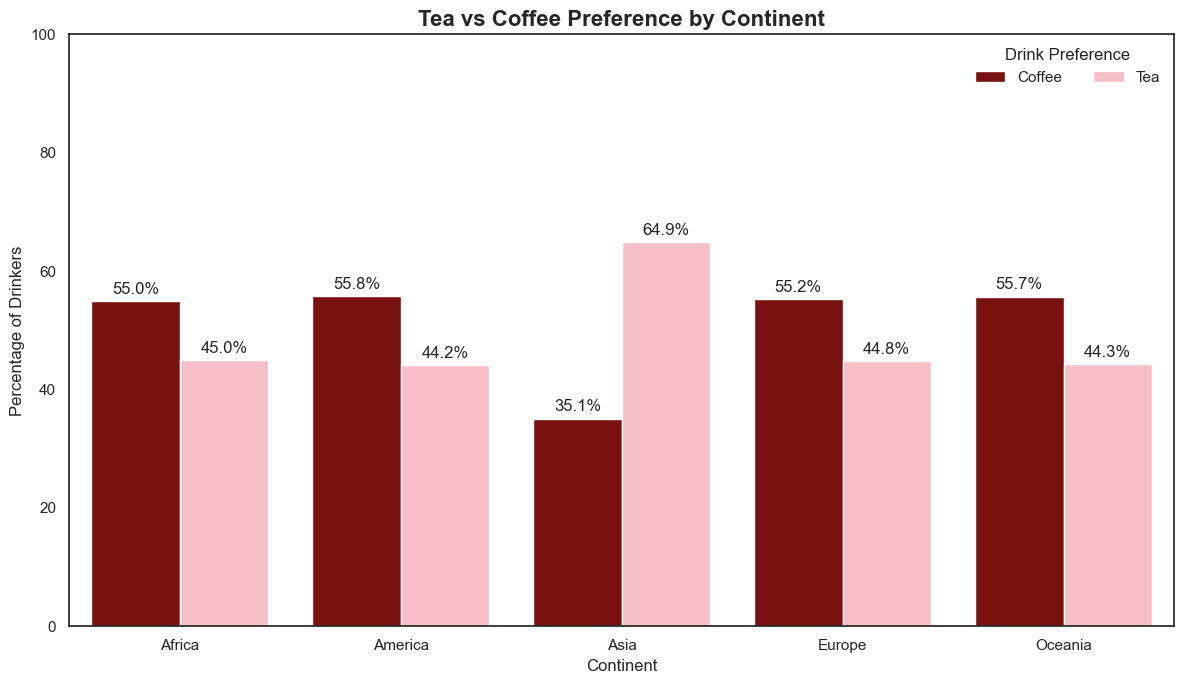

In [7]:
sns.set_theme(style="white")

plt.figure(figsize=(12, 7), facecolor='white')

ax = sns.barplot(
    data=continent_pref,
    x='continent',
    y='percentage',
    hue='drink_preference',
    hue_order=['Coffee', 'Tea'],
    palette=['darkred', 'lightpink']
)

ax.set_facecolor('white')
ax.grid(False)

plt.title('Tea vs Coffee Preference by Continent', fontsize=16, fontweight='bold')
plt.xlabel('Continent', fontsize=12)
plt.ylabel('Percentage of Drinkers', fontsize=12)
plt.ylim(0, 100)

plt.legend(
    title='Drink Preference',
    loc='upper right',
    ncol=2,
    frameon=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## Change over time — whether preferences are shifting

In [8]:
df.head()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,Bangladesh,Asia,2015,56,Male,Low,Coffee,Mocha,Modern,2.3,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
1,Bangladesh,Asia,2015,61,Other,High,Tea,Oolong Tea,Traditional,1.3,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2,Bangladesh,Asia,2015,59,Female,Low,Coffee,Americano,Modern,3.2,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
3,Bangladesh,Asia,2015,41,Other,High,Coffee,Cappuccino,Modern,3.0,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
4,Bangladesh,Asia,2015,43,Other,Middle,Tea,Green Tea,Traditional,1.9,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


In [9]:
df.columns = df.columns.str.strip()
df.columns.tolist()

['country',
 'continent',
 'year',
 'age',
 'gender',
 'income_level',
 'drink_preference',
 'favorite_drink',
 'drink_category',
 'cups_per_day',
 'drink_temperature',
 'sugar_level',
 'milk_usage',
 'caffeine_preference',
 'taste_score',
 'bitterness',
 'acidity',
 'aroma_score',
 'monthly_spend',
 'price_per_cup',
 'home_vs_cafe_ratio',
 'work_type',
 'sleep_hours',
 'stress_level',
 'exercise_frequency',
 'bmi',
 'hydration_level',
 'heart_rate',
 'drink_reason',
 'social_setting',
 'time_of_day',
 'loyalty_brand',
 'experiment_new_drinks',
 'satisfaction_level']

In [10]:
yearly_pref = (
    df.groupby(['year', 'drink_preference'])
      .size()
      .reset_index(name='count')
)

yearly_pref['percentage'] = (
    yearly_pref.groupby('year')['count']
    .transform(lambda x: x / x.sum() * 100)
)

yearly_pref.head()

,year,drink_preference,count,percentage
0,2015,Coffee,743,49.533333
1,2015,Tea,757,50.466667
2,2016,Coffee,733,48.866667
3,2016,Tea,767,51.133333
4,2017,Coffee,700,46.666667


In [11]:
from ipywidgets import interact, widgets

In [12]:
from ipywidgets import interact, widgets

def plot_preference_trend(selected_continent):
    # Filter data based on dropdown selection
    if selected_continent == 'Overall':
        filtered_df = df.copy()
    else:
        filtered_df = df[df['continent'] == selected_continent]

    # Create yearly summary for the selected continent
    yearly_pref = (
        filtered_df.groupby(['year', 'drink_preference'])
        .size()
        .reset_index(name='count')
    )

    yearly_pref['percentage'] = (
        yearly_pref.groupby('year')['count']
        .transform(lambda x: x / x.sum() * 100)
    )

    # Create chart
    plt.figure(figsize=(12, 7), facecolor='white')

    ax = sns.lineplot(
        data=yearly_pref,
        x='year',
        y='percentage',
        hue='drink_preference',
        hue_order=['Coffee', 'Tea'],
        palette=['darkred', 'lightpink'],
        marker='o',
        linewidth=3
    )

    ax.set_facecolor('white')
    ax.grid(False)

    plt.title(f'Tea vs Coffee Preference Over Time - {selected_continent}', fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Percentage of Drinkers', fontsize=12)

    plt.ylim(25, 75)
    plt.xticks(sorted(yearly_pref['year'].unique()))

    plt.legend(
        title='Drink Preference',
        loc='upper right',
        ncol=2,
        frameon=False
    )


    plt.tight_layout()
    plt.show()

continent_options = ['Overall'] + sorted(df['continent'].dropna().unique().tolist())

interact(
    plot_preference_trend,
    selected_continent=widgets.Dropdown(
        options=continent_options,
        value='Overall',
        description='Continent:'
    )
);

interactive(children=(Dropdown(description='Continent:', options=('Overall', 'Africa', 'America', 'Asia', 'Eur…

### Key Insight
Tea remains slightly ahead of coffee across most years, but the gap is small and the overall pattern is stable.

## Who drinks what — age, gender, income and time of the day

In [13]:
from ipywidgets import interact, widgets

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import widgets, interactive_output, VBox

# ----------------------------
# Shared dropdown widgets
# ----------------------------
drink_dropdown = widgets.Dropdown(
    options=sorted(df['drink_preference'].dropna().unique().tolist()),
    value='Tea' if 'Tea' in df['drink_preference'].unique() else sorted(df['drink_preference'].dropna().unique().tolist())[0],
    description='Drink:'
)

gender_dropdown = widgets.Dropdown(
    options=sorted(df['gender'].dropna().unique().tolist()),
    value=sorted(df['gender'].dropna().unique().tolist())[0],
    description='Gender:'
)

# ----------------------------
# Heatmap function
# ----------------------------
def plot_social_matrix(selected_drink, selected_gender):
    filtered_df = df[
        (df['drink_preference'] == selected_drink) &
        (df['gender'] == selected_gender)
    ].copy()

    grouped = (
        filtered_df.groupby(['income_level', 'time_of_day', 'social_setting'])
        .size()
        .reset_index(name='count')
    )

    if grouped.empty:
        print("No data available for this selection.")
        return

    grouped['total_in_cell'] = (
        grouped.groupby(['income_level', 'time_of_day'])['count']
        .transform('sum')
    )

    grouped['percentage'] = (grouped['count'] / grouped['total_in_cell']) * 100

    dominant_setting = (
        grouped.sort_values('percentage', ascending=False)
        .drop_duplicates(subset=['income_level', 'time_of_day'])
    )

    heatmap_values = dominant_setting.pivot(
        index='income_level',
        columns='time_of_day',
        values='percentage'
    )

    dominant_setting['label'] = (
        dominant_setting['social_setting'] + '\n(' +
        dominant_setting['percentage'].round(1).astype(str) + '%)'
    )

    heatmap_labels = dominant_setting.pivot(
        index='income_level',
        columns='time_of_day',
        values='label'
    )

    income_order = ['Low', 'Middle', 'High']
    existing_income_order = [x for x in income_order if x in heatmap_values.index]

    time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    existing_time_order = [x for x in time_order if x in heatmap_values.columns]

    heatmap_values = heatmap_values.reindex(existing_income_order)
    heatmap_labels = heatmap_labels.reindex(existing_income_order)

    heatmap_values = heatmap_values[existing_time_order]
    heatmap_labels = heatmap_labels[existing_time_order]

    plt.figure(figsize=(12, 6), facecolor='white')

    ax = sns.heatmap(
        heatmap_values,
        annot=heatmap_labels,
        fmt='',
        cmap=shared_cmap,
        linewidths=2,
        linecolor='white',
        cbar=True
    )

    ax.set_facecolor('white')

    plt.title(
        f'Dominant Social Setting by Income Level and Time of Day\n{selected_drink} Drinkers - {selected_gender}',
        fontsize=16,
        fontweight='bold'
    )
    plt.xlabel('Time of Day', fontsize=12)
    plt.ylabel('Income Level', fontsize=12)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ----------------------------
# Motivation chart function
# ----------------------------
def plot_motivation(selected_drink, selected_gender):
    filtered_df = df[
        (df['drink_preference'] == selected_drink) &
        (df['gender'] == selected_gender)
    ].copy()

    if filtered_df.empty:
        print("No data available for this selection.")
        return

    reason_table = (
        filtered_df['drink_reason']
        .value_counts(normalize=True)
        .mul(100)
        .rename_axis('drink_reason')
        .reset_index(name='percentage')
    )

    reason_order = ['Taste', 'Habit', 'Social', 'Energy']
    reason_table['drink_reason'] = pd.Categorical(
        reason_table['drink_reason'],
        categories=reason_order,
        ordered=True
    )
    reason_table = reason_table.sort_values('drink_reason')

    color_map = {
    'Taste':  '#f4a6b7',  # pink
    'Habit':  '#800000',  # maroon
    'Social': '#97978F',  # grey
    'Energy': '#c75c72'   # medium rose
    }

    colors = [color_map.get(reason, '#cccccc') for reason in reason_table['drink_reason']]

    fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')
    ax.set_facecolor('white')

    bars = ax.barh(
        reason_table['drink_reason'],
        reason_table['percentage'],
        color=colors,
        edgecolor='white',
        linewidth=1.5,
        height=0.6
    )

    ax.set_title(
        f'Motivation for Drinking {selected_drink}\n{selected_gender}',
        fontsize=18,
        fontweight='bold',
        pad=20
    )
    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_xticks([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=12, length=0)

    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_visible(False)

    for bar, value in zip(bars, reason_table['percentage']):
        ax.text(
            value - 1 if value > 10 else value + 1,
            bar.get_y() + bar.get_height() / 2,
            f'{value:.1f}%',
            va='center',
            ha='right' if value > 10 else 'left',
            fontsize=10,
            color='white' if value > 10 else 'black',
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

# ----------------------------
# Connect both charts to shared dropdowns
# ----------------------------
heatmap_out = interactive_output(
    plot_social_matrix,
    {'selected_drink': drink_dropdown, 'selected_gender': gender_dropdown}
)

motivation_out = interactive_output(
    plot_motivation,
    {'selected_drink': drink_dropdown, 'selected_gender': gender_dropdown}
)

display(VBox([drink_dropdown, gender_dropdown, heatmap_out, motivation_out]))

### Key Insights: 
Taken across both the charts, the heatmaps and motivation charts show that tea and coffee consumption differ more by context than by stated motivation. Motivations such as taste, habit, energy, and social reasons remain relatively balanced across groups, but the dominant social setting changes clearly by drink type, gender, income, and time of day. Tea is more often associated with family, friends, and socially embedded routines, while coffee appears more closely tied to solitary, work-related, or functional consumption patterns.

# Wellness

In [15]:
df['exercise_frequency'].unique()

array(['Moderate', 'High', 'Low'], dtype=object)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (12, 7)

shared_cmap = LinearSegmentedColormap.from_list(
    "custom_pink_red",
    ['#fbe6eb', '#f4a6b7', '#800000']
)

In [9]:
df = pd.read_excel("/Users/deepti/Documents/My projects/tea_vs_coffee_global_final.xlsx", engine="openpyxl")
df.head()

,country,continent,year,age,gender,income_level,drink_preference,favorite_drink,drink_category,cups_per_day,...,exercise_frequency,bmi,hydration_level,heart_rate,drink_reason,social_setting,time_of_day,loyalty_brand,experiment_new_drinks,satisfaction_level
0,Bangladesh,Asia,2015,56,Male,Low,Coffee,Mocha,Modern,2.3,...,Moderate,26.9,9,86,Taste,Work,Afternoon,Explorer,No,3
1,Bangladesh,Asia,2015,61,Other,High,Tea,Oolong Tea,Traditional,1.3,...,High,20.9,1,95,Habit,Family,Night,Explorer,No,6
2,Bangladesh,Asia,2015,59,Female,Low,Coffee,Americano,Modern,3.2,...,Low,31.6,1,84,Taste,Alone,Night,Brand Loyal,No,8
3,Bangladesh,Asia,2015,41,Other,High,Coffee,Cappuccino,Modern,3.0,...,Moderate,33.1,1,94,Energy,Work,Afternoon,Brand Loyal,Yes,5
4,Bangladesh,Asia,2015,43,Other,Middle,Tea,Green Tea,Traditional,1.9,...,High,29.8,2,65,Social,Family,Night,Explorer,No,7


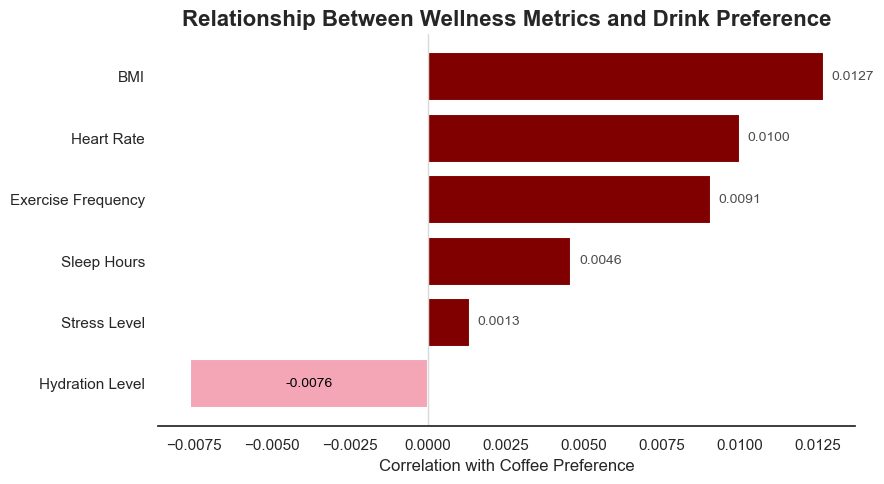

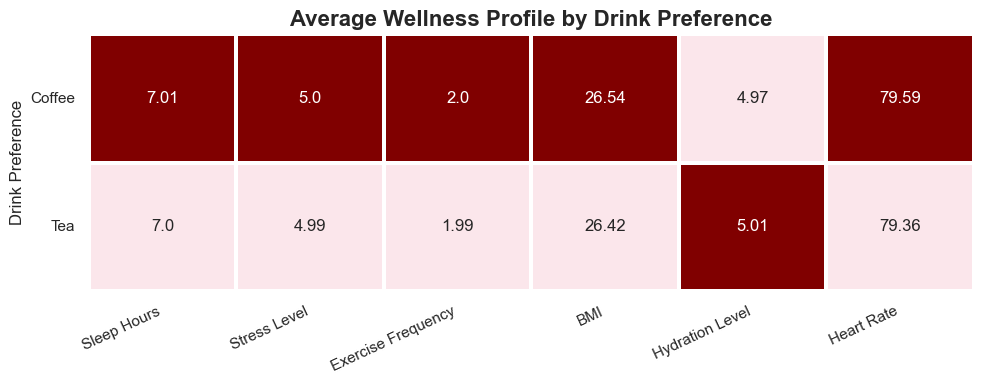

,Tea,Coffee,Coffee - Tea
Sleep Hours,7.00,7.01,0.01
Stress Level,4.99,5.00,0.01
Exercise Frequency,1.99,2.00,0.01
BMI,26.42,26.54,0.12
Hydration Level,5.01,4.97,-0.04
Heart Rate,79.36,79.59,0.23


In [17]:
# ================================
# WELLNESS ANALYSIS - PRESENTABLE VERSION
# ================================

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ----------------
# Shared styling
# ----------------
sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (12, 7)

dark_red = '#800000'
pink = '#f4a6b7'
light_pink = '#fbe6eb'
grey = '#d9d9d9'
rose = '#c75c72'

shared_cmap = LinearSegmentedColormap.from_list(
    "custom_pink_red",
    [light_pink, pink, dark_red]
)

# ----------------
# Encode drink preference
# Tea = 0, Coffee = 1
# ----------------
df['drink_pref_encoded'] = df['drink_preference'].map({'Tea': 0, 'Coffee': 1})

# ----------------
# Convert exercise frequency to numeric
# ----------------
exercise_map = {
    'Low': 1,
    'Moderate': 2,
    'High': 3
}
df['exercise_frequency_num'] = df['exercise_frequency'].map(exercise_map)

# ----------------
# Wellness columns
# ----------------
health_corr_cols = [
    'sleep_hours',
    'stress_level',
    'exercise_frequency_num',
    'bmi',
    'hydration_level',
    'heart_rate'
]

pretty_names = {
    'sleep_hours': 'Sleep Hours',
    'stress_level': 'Stress Level',
    'exercise_frequency_num': 'Exercise Frequency',
    'bmi': 'BMI',
    'hydration_level': 'Hydration Level',
    'heart_rate': 'Heart Rate'
}

# ----------------
# 1. Correlation with drink preference
# ----------------
corr_df = df[health_corr_cols + ['drink_pref_encoded']].corr(numeric_only=True)
drink_corr = corr_df['drink_pref_encoded'].drop('drink_pref_encoded').sort_values()

corr_plot = drink_corr.reset_index()
corr_plot.columns = ['metric', 'correlation']
corr_plot['metric'] = corr_plot['metric'].map(pretty_names)

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.set_facecolor('white')

colors = [pink if x < 0 else dark_red for x in corr_plot['correlation']]

bars = ax.barh(
    corr_plot['metric'],
    corr_plot['correlation'],
    color=colors,
    edgecolor='white',
    linewidth=1.5
)

ax.grid(False)
ax.set_title('Relationship Between Wellness Metrics and Drink Preference', fontsize=16, fontweight='bold')
ax.set_xlabel('Correlation with Coffee Preference', fontsize=12)
ax.set_ylabel('')

# Add a vertical reference line at 0
ax.axvline(0, color=grey, linewidth=1)

# Add value labels with better placement
for bar, value in zip(bars, corr_plot['correlation']):
    y = bar.get_y() + bar.get_height() / 2

    if value < 0:
        # Put label inside the negative bar
        ax.text(
            value / 2,
            y,
            f'{value:.4f}',
            va='center',
            ha='center',
            fontsize=10,
            color='black'
        )
    else:
        # Put label just outside the positive bar
        ax.text(
            value + 0.00025,
            y,
            f'{value:.4f}',
            va='center',
            ha='left',
            fontsize=10,
            color='#4d4d4d'
        )

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# ----------------
# 2. Average wellness profile by drink preference
# ----------------
wellness_means = df.groupby('drink_preference')[
    ['sleep_hours', 'stress_level', 'bmi', 'hydration_level', 'heart_rate']
].mean().round(2)

exercise_means = df.groupby('drink_preference')['exercise_frequency_num'].mean().round(2)
wellness_means['exercise_frequency_num'] = exercise_means

wellness_means = wellness_means[
    ['sleep_hours', 'stress_level', 'exercise_frequency_num', 'bmi', 'hydration_level', 'heart_rate']
]

# Normalize for visual comparison
wellness_scaled = wellness_means.copy()
for col in wellness_scaled.columns:
    col_min = wellness_scaled[col].min()
    col_max = wellness_scaled[col].max()
    if col_max != col_min:
        wellness_scaled[col] = (wellness_scaled[col] - col_min) / (col_max - col_min)
    else:
        wellness_scaled[col] = 0.5

annot_values = wellness_means.copy()
annot_values.columns = [pretty_names[c] for c in annot_values.columns]
wellness_scaled.columns = [pretty_names[c] for c in wellness_scaled.columns]

plt.figure(figsize=(10, 4), facecolor='white')
ax = sns.heatmap(
    wellness_scaled,
    annot=annot_values,
    fmt='',
    cmap=shared_cmap,
    linewidths=1.5,
    linecolor='white',
    cbar=False
)

ax.set_facecolor('white')
plt.title('Average Wellness Profile by Drink Preference', fontsize=16, fontweight='bold')
plt.xlabel('')
plt.ylabel('Drink Preference', fontsize=12)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------
# 3. Compact summary table
# ----------------
wellness_diff = (wellness_means.loc['Coffee'] - wellness_means.loc['Tea']).round(2)
summary_table = pd.DataFrame({
    'Tea': wellness_means.loc['Tea'],
    'Coffee': wellness_means.loc['Coffee'],
    'Coffee - Tea': wellness_diff
}).round(2)

summary_table.index = summary_table.index.map(pretty_names)

display(summary_table)

### Wellness Insight
The relationship between drink preference and wellness is very weak overall. Tea and coffee drinkers show only minimal differences across sleep, stress, exercise frequency, BMI, hydration, and heart rate, suggesting that beverage choice alone is not a strong predictor of wellness outcomes in this dataset.

# Business Insights

In [18]:
# ================================
# BUSINESS INSIGHT CHART
# Spend vs Home/Cafe Behavior vs Satisfaction
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate data
business_summary = (
    df.groupby(['drink_preference', 'loyalty_brand'])[
        ['monthly_spend', 'home_vs_cafe_ratio', 'satisfaction_level']
    ]
    .mean()
    .reset_index()
)

business_summary

,drink_preference,loyalty_brand,monthly_spend,home_vs_cafe_ratio,satisfaction_level
0,Coffee,Brand Loyal,51.881102,0.499926,4.992050
1,Coffee,Explorer,51.689452,0.499984,5.043025
2,Tea,Brand Loyal,51.604268,0.497366,5.051316
3,Tea,Explorer,52.421596,0.501850,5.026134


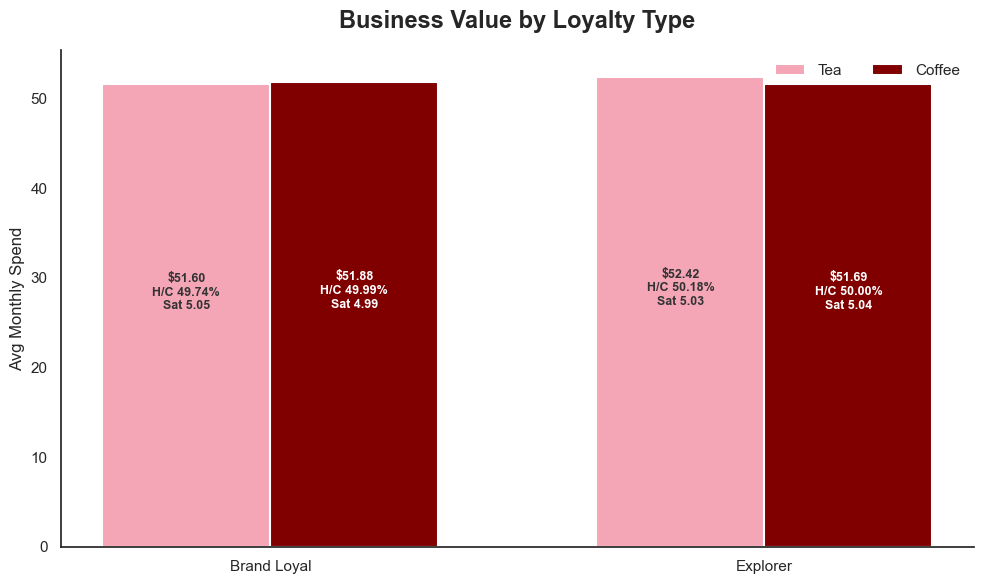

In [20]:
# ================================
# BUSINESS INSIGHT - POLISHED VERSION
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Create summary table
business_summary = (
    df.groupby(['loyalty_brand', 'drink_preference'])[
        ['monthly_spend', 'home_vs_cafe_ratio', 'satisfaction_level']
    ]
    .mean()
    .reset_index()
)

# 2. Convert and round values
business_summary['home_vs_cafe_pct'] = (business_summary['home_vs_cafe_ratio'] * 100).round(2)
business_summary['monthly_spend'] = business_summary['monthly_spend'].round(2)
business_summary['satisfaction_level'] = business_summary['satisfaction_level'].round(2)

# 3. Set clean ordering
loyalty_order = ['Brand Loyal', 'Explorer']
drink_order = ['Tea', 'Coffee']

business_summary['loyalty_brand'] = pd.Categorical(
    business_summary['loyalty_brand'],
    categories=loyalty_order,
    ordered=True
)

business_summary['drink_preference'] = pd.Categorical(
    business_summary['drink_preference'],
    categories=drink_order,
    ordered=True
)

business_summary = business_summary.sort_values(['loyalty_brand', 'drink_preference'])

# 4. Pivot monthly spend for bar heights
pivot_spend = business_summary.pivot(
    index='loyalty_brand',
    columns='drink_preference',
    values='monthly_spend'
)

pivot_spend = pivot_spend.reindex(loyalty_order)

# 5. Prepare plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('white')

x = np.arange(len(pivot_spend.index))
width = 0.34

tea_vals = pivot_spend['Tea'].values if 'Tea' in pivot_spend.columns else np.zeros(len(x))
coffee_vals = pivot_spend['Coffee'].values if 'Coffee' in pivot_spend.columns else np.zeros(len(x))

bars_tea = ax.bar(
    x - width/2,
    tea_vals,
    width,
    label='Tea',
    color='#f4a6b7',
    edgecolor='white',
    linewidth=1.5
)

bars_coffee = ax.bar(
    x + width/2,
    coffee_vals,
    width,
    label='Coffee',
    color='#800000',
    edgecolor='white',
    linewidth=1.5
)

# 6. Add compact labels inside bars
for bars, drink in [(bars_tea, 'Tea'), (bars_coffee, 'Coffee')]:
    for i, bar in enumerate(bars):
        loyalty = pivot_spend.index[i]

        row = business_summary[
            (business_summary['loyalty_brand'] == loyalty) &
            (business_summary['drink_preference'] == drink)
        ].iloc[0]

        label = (
            f"${row['monthly_spend']:.2f}\n"
            f"H/C {row['home_vs_cafe_pct']:.2f}%\n"
            f"Sat {row['satisfaction_level']:.2f}"
        )

        # Choose label color based on bar color
        text_color = 'white' if drink == 'Coffee' else '#333333'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 0.55,
            label,
            ha='center',
            va='center',
            fontsize=9,
            color=text_color,
            fontweight='bold'
        )

# 7. Styling
ax.set_title('Business Value by Loyalty Type', fontsize=17, fontweight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('Avg Monthly Spend', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(['Brand Loyal', 'Explorer'], fontsize=11)

# Add a little space above bars
ax.set_ylim(0, max(max(tea_vals), max(coffee_vals)) + 3)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.legend(frameon=False, loc='upper right', ncol=2)

plt.tight_layout()
plt.show()

### Business Insight
Both Tea and Coffee generate similar average monthly spend across loyalty types, while home-versus-cafe behavior remains close to balanced. Satisfaction differences are also modest, suggesting that loyalty segment and drink type do not create major business gaps in this dataset.

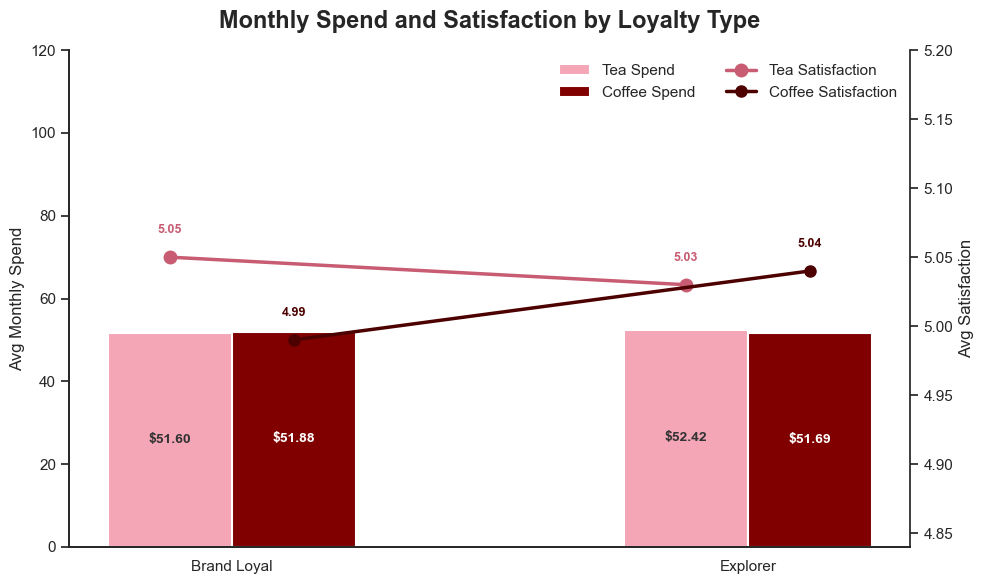

In [23]:
# ================================
# BUSINESS INSIGHT - CLEAN COMBO CHART
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Create summary table
business_summary = (
    df.groupby(['loyalty_brand', 'drink_preference'])[
        ['monthly_spend', 'satisfaction_level']
    ]
    .mean()
    .reset_index()
)

# 2. Round values
business_summary['monthly_spend'] = business_summary['monthly_spend'].round(2)
business_summary['satisfaction_level'] = business_summary['satisfaction_level'].round(2)

# 3. Set order
loyalty_order = ['Brand Loyal', 'Explorer']
drink_order = ['Tea', 'Coffee']

business_summary['loyalty_brand'] = pd.Categorical(
    business_summary['loyalty_brand'],
    categories=loyalty_order,
    ordered=True
)

business_summary['drink_preference'] = pd.Categorical(
    business_summary['drink_preference'],
    categories=drink_order,
    ordered=True
)

business_summary = business_summary.sort_values(['loyalty_brand', 'drink_preference'])

# 4. Pivot data
spend_pivot = business_summary.pivot(
    index='loyalty_brand',
    columns='drink_preference',
    values='monthly_spend'
).reindex(loyalty_order)

sat_pivot = business_summary.pivot(
    index='loyalty_brand',
    columns='drink_preference',
    values='satisfaction_level'
).reindex(loyalty_order)

# 5. Prepare chart
fig, ax1 = plt.subplots(figsize=(10, 6), facecolor='white')
ax1.set_facecolor('white')

x = np.arange(len(loyalty_order))
width = 0.24

tea_spend = spend_pivot['Tea'].values if 'Tea' in spend_pivot.columns else np.zeros(len(x))
coffee_spend = spend_pivot['Coffee'].values if 'Coffee' in spend_pivot.columns else np.zeros(len(x))

# 6. Bars for monthly spend
bars_tea = ax1.bar(
    x - width/2,
    tea_spend,
    width,
    label='Tea Spend',
    color='#f4a6b7',
    edgecolor='white',
    linewidth=1.5,
    zorder=1
)

bars_coffee = ax1.bar(
    x + width/2,
    coffee_spend,
    width,
    label='Coffee Spend',
    color='#800000',
    edgecolor='white',
    linewidth=1.5,
    zorder=1
)

# 7. Left axis styling
ax1.set_title('Monthly Spend and Satisfaction by Loyalty Type', fontsize=17, fontweight='bold', pad=16)
ax1.set_ylabel('Avg Monthly Spend', fontsize=12)
ax1.set_xlabel('')
ax1.set_xticks(x)
ax1.set_xticklabels(loyalty_order, fontsize=11)

# Raise bar axis limit so the line sits clearly above bars
ax1.set_ylim(0, 120)

ax1.grid(False)
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# Spend labels inside bars
for bars, drink in [(bars_tea, 'Tea'), (bars_coffee, 'Coffee')]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width()/2,
            height * 0.50,
            f'${height:.2f}',
            ha='center',
            va='center',
            fontsize=10,
            color='white' if drink == 'Coffee' else '#333333',
            fontweight='bold',
            zorder=2
        )

# 8. Secondary axis for satisfaction
ax2 = ax1.twinx()

tea_sat = sat_pivot['Tea'].values if 'Tea' in sat_pivot.columns else np.zeros(len(x))
coffee_sat = sat_pivot['Coffee'].values if 'Coffee' in sat_pivot.columns else np.zeros(len(x))

line1, = ax2.plot(
    x - width/2,
    tea_sat,
    color='#c75c72',
    marker='o',
    linewidth=2.5,
    markersize=9,
    label='Tea Satisfaction',
    zorder=5
)

line2, = ax2.plot(
    x + width/2,
    coffee_sat,
    color='#4d0000',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Coffee Satisfaction',
    zorder=5
)

ax2.set_ylabel('Avg Satisfaction', fontsize=12)
ax2.spines['top'].set_visible(False)

# Keep satisfaction axis tight but above bar labels visually
all_sat = np.concatenate([tea_sat, coffee_sat])
ax2.set_ylim(all_sat.min() - 0.15, all_sat.max() + 0.15)

# Satisfaction labels above points
for xpos, val in zip(x - width/2, tea_sat):
    ax2.text(
        xpos,
        val + 0.015,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#c75c72',
        fontweight='bold',
        zorder=6
    )

for xpos, val in zip(x + width/2, coffee_sat):
    ax2.text(
        xpos,
        val + 0.015,
        f'{val:.2f}',
        ha='center',
        va='bottom',
        fontsize=9,
        color='#4d0000',
        fontweight='bold',
        zorder=6
    )

# 9. Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    frameon=False,
    loc='upper right',
    ncol=2
)

plt.tight_layout()
plt.show()

### Business Insights
Monthly spend is broadly similar across Tea and Coffee loyalty segments, and satisfaction remains closely aligned as well. This suggests that neither drink type nor loyalty category creates a strong commercial separation in the dataset.